# Serpientes y escaleras y Problema del Ratón

Hernández Ramírez Frida Karol 

## Serpientes y escaleras 

In [5]:
!pip install numpy matplotlib sympy

mambajs 0.19.13

Process pip requirements ...

Requirement numpy already handled by conda/micromamba/mamba.
Requirement matplotlib already handled by conda/micromamba/mamba.


In [6]:
import random
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

El tablero tiene 20 casillas, de las cuales no todas son iguales. Las casillas especiales son:

- Escalera: 3 → 11
- Escalera: 15 → 19
- Serpiente: 13 → 4
- Serpiente: 17 → 9

In [7]:
# Almacenamos serpientes y escaleras, el primer número representa la casilla donde caemos
# y el segundo número representa la casilla a la que nos moveremos

especiales = {
    3:11,
    15:19,
    13:4,
    17:9 }

(Las escaleras nos dejan avanzar saltandonos casillas y las serpientes nos hacen retroceder)

Ahora construiremos una función que detectará las casillas especiales:

In [8]:
# Función que revisa si caimos en una serpiente o escalera

def mover(posicion):

    # Revisamos si la casilla es especial
    if posicion in especiales:

        # Regresamos la nueva posición
        return especiales[posicion]

    # y si no ocurre nada especial
    return posicion

Ahora vamos a simular una partida, en cada turno:

- Lanzamos un dado
- Avanzamos en el tablero
- Revisamos si caimos en una serpiente o escalera
- Guardamos el recorrido realizado.

In [11]:
# Posición inicial
posicion = 1

# Contador de tiradas
tiradas = 0

# Lista donde guardamos todo el recorrido
historial = [posicion]

# Continuamow mientras no lleguemos a la meta (20)
while posicion < 20:

    # Lanzamiento del dado
    dado = random.randint(1,6)

    # Avanzamos
    posicion += dado

    if posicion > 20:
        posicion = 20

    posicion = mover(posicion)

    # Guardamos
    historial.append(posicion)
    
    tiradas += 1

print(f"Número total de tiradas: {tiradas}")
print(f"Recorrido realizado: {historial}")

Número total de tiradas: 24
Recorrido realizado: [1, 5, 10, 12, 9, 10, 11, 9, 11, 4, 8, 10, 4, 9, 10, 4, 6, 10, 4, 10, 14, 9, 14, 19, 20]


Observamos que cuando los valores suben quiere decir que caimos en una escalera y cuando los valores bajan quiere decir que caimos en una casilla con serpiente.

Usando el método de Monte Carlo vamos a realizar simulaciones independientes para poder estimar realmente el comportamiento promedio de este juego.

In [14]:
def juego():

    # Posición inicial
    posicion = 1

    # Contador de tiradas
    tiradas = 0

    # Mientras no lleguemos a la meta (casilla 20)
    while posicion < 20:

        # Lanzamiento del dado
        dado = random.randint(1,6)

        # Movimiento de casillas
        posicion += dado

        # Si superamos la casilla final nos regresamos
        if posicion > 20:
            posicion = 20

        posicion = mover(posicion)
            
        tiradas += 1

    return tiradas

Este método consiste en repetir el experimento (aleatorio) muchas veces para poder aproximar probabilidades, en nuestro caso vamos a  repetir el juego muchas veces para así aproximar el número esperado de tiradas.

In [16]:
# Número total de simulaciones

N = 10000

# Lista para guardar resultados

resultados = []

# Simulaciones

for i in range(N):

    resultado = juego()

    resultados.append(resultado)

# Calculando promedio

promedio = np.mean(resultados)

print(f"Promedio de tiradas: {promedio:.2f}")

Promedio de tiradas: 7.02


Por lo tanto, necesitamos un promedio de 7 tiradas para poder acabar el juego

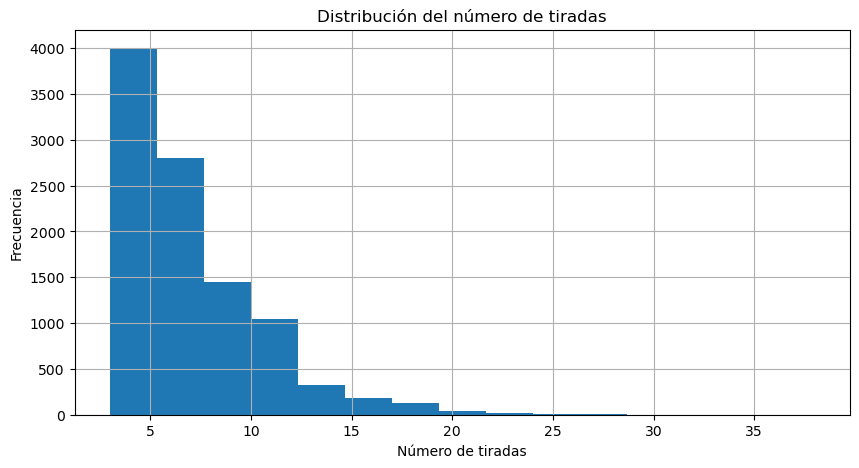

In [17]:
# Histograma:

plt.figure(figsize=(10,5))

plt.hist(
    resultados,
    bins = 15
)

plt.title("Distribución del número de tiradas")

plt.xlabel("Número de tiradas")
plt.ylabel("Frecuencia")

plt.grid()

plt.show()

Observamos que la mayor parte de las partidas terminan entre 4 y 10 tiradas, mientras aumentan las tiradas,, la frecuencia va disminuyendo... La mayoría de las partidas terminan rápido, las que terminan lento es debido a caer en una casilla con serpientes.

El juego lo podemos modelar con una cadena de Markov ya que el siguiente movimiento depende únicamente de la posición actual del jugador.
La simulación Monte Carlo nos permitió aproximar el promedio de tiradas que necesitamos para poder terminar el juego.
Además, las gráficas nos ayudaron a ver el comportamiento aleatorio y las consecuencias de las serpientes y escaleras.

## Laberinto

Tenemos que:

- El ratón inicia en la casilla 0

- La comida se encuentra en la casilla 7

- La descarga eléctrica se encuentra en la casilla 8

- En cada paso el ratón elige aleatoriamente uno de los caminos disponibles

Las conexiones entre casillas son:

- 0 conecta con 1 y 2
- 1 conecta con 0, 3 y 7
- 2 conecta con 0, 3 y 8
- 3 conecta con 1, 2, 4 y 5
- 4 conecta con 3, 6 y 7
- 5 conecta con 3, 6 y 8
- 6 conecta con 4 y 5

In [18]:
# Almacenamos las conexiones del laberinto

conexiones = {
    0:[1,2],
    1:[0,3,7],
    2:[0,3,8],
    3:[1,2,4,5],
    4:[3,6,7],
    5:[3,6,8],
    6:[4,5]}

Por ejemplo:

$0 \rightarrow [1,2]$ , significa que desde la casilla $0$ el ratón puede moverse a la casilla $1$ o a la casilla $2$

Ahora simularemos un recorrido aleatorio del ratón en el laberinto

In [19]:
estado = 0

# Lista dondr guardamos el recorrido

historial = [estado]

# Continuamos hasta llegar a comida o descarga elec

while True:

    # Si llega a la comida:
    if estado == 7:

        print("El ratón encontró la comida")
        break

    # Si llega a la descarga eléctrica:
    if estado == 8:

        print("El ratón recibió una descarga")
        break

    # Movimiento aleatorio

    estado = random.choice(conexiones[estado])

    # Guardamos el nuevo estado

    historial.append(estado)

print("Recorrido realizado:")
print(historial)

El ratón recibió una descarga
Recorrido realizado:
[0, 2, 0, 2, 8]


Nuestro proceso termina cuando el ratón alcanza:

- la comida, estado 7
- o la descarga eléctrica, estado 8 (como en este caso)

Usaremos el método de Monte Carlo para repetir nuestro procesos más veces:

In [21]:
def raton():
    
    estado = 0

    # El proceso continúa hasta llegar a uno de los estados abs

    while True:

        # El ratón encontró comida
        if estado == 7:
            return 1

        # El ratón recibió descarga
        if estado == 8:
            return 0

        # Elegimos movimiento aleatorio

        estado = random.choice(conexiones[estado])

La función anterior devuelve:

- 1 si el ratón alcanza la comida
- 0 si llega a la descarga eléctrica

In [22]:
# Número de simulaciones

N = 10000

# Lista para guardar resultados

resultados = []

# Simulaciones

for i in range(N):

    resultado = raton()

    resultados.append(resultado)

probabilidad = np.mean(resultados)

print(f"Probabilidad aproximada de llegar a la comida: {probabilidad:.4f}")

Probabilidad aproximada de llegar a la comida: 0.5054


Por lo tanto, tenemos una probabilidad del 50.54% de que el ratón alcance la comida

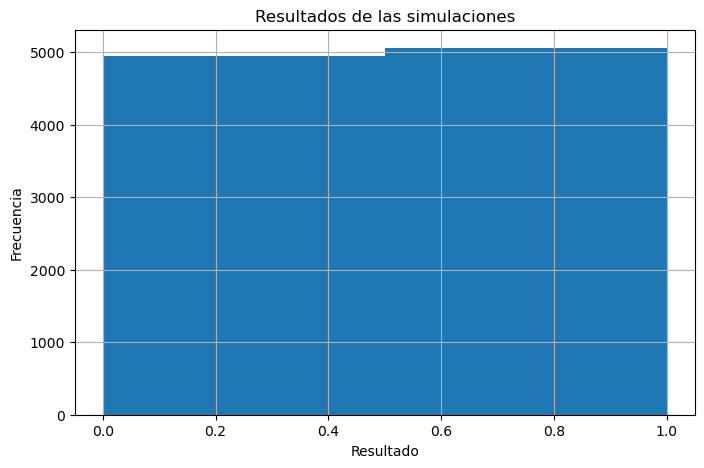

In [23]:
# Histograma:

plt.figure(figsize=(8,5))

plt.hist(
    resultados,
    bins = 2
)

plt.title("Resultados de las simulaciones")

plt.xlabel("Resultado")
plt.ylabel("Frecuencia")

plt.grid()

plt.show()

Observamos que las 2 posibilidades ocurren con frecuencias similares por lo que ninguna domina.

El problema lo podemos modelar con una cadena de Markov ya que el siguiente movimiento depende únicamente de la posición actual del ratón. La simulación Monte Carlo nos permitió aproximar la probabilidad de alcanzar la comida.